In [20]:
import csv
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import seaborn as sns

In [2]:
attacks1 = pd.read_csv("pirates_slice1.csv", sep=';', decimal=',')
attacks2 = pd.read_csv("pirates_slice2.csv", sep=';', decimal=',')

indicators1 = pd.read_csv("indicators1998-2003.csv", sep=';', decimal=',')
indicators2 = pd.read_csv("indicators2006-2011.csv", sep=';', decimal=',')

#drop duplicates lines
indicators1 = indicators1.drop_duplicates(subset=["country", "year"])
indicators2 = indicators2.drop_duplicates(subset=["country", "year"])

In [3]:
#get year from date
attacks1['year'] = pd.to_datetime(attacks1['date']).dt.year

#drop rows with missing attack_type or eez_country (drop controlled in other notebook)
attacks1 = attacks1.dropna(subset=['attack_type', 'eez_country'])

#joining year + country
merged1 = attacks1.merge(
    indicators1[['country', 'year', 'GDP']],
    left_on=['eez_country', 'year'],
    right_on=['country', 'year'],
    how='left'
)

merged1 = merged1.dropna(subset=['GDP']) #drop rows missing GDP (2)

print(merged1.shape)
print(merged1['attack_type'].value_counts())
print(merged1['GDP'].describe())

(2073, 19)
attack_type
Boarding      750
Boarded       692
Attempted     528
Hijacked       98
Explosion       3
Fired Upon      1
Detained        1
Name: count, dtype: int64
count     2073.000000
mean      1590.827280
std       2791.011533
min        102.597978
25%        463.948170
50%        780.190201
75%       1339.293577
max      39496.485880
Name: GDP, dtype: float64


## Collapsing 'boarded' and 'boarding' into one category, 'boarded', slice 1

In [4]:
merged1 = merged1[merged1['attack_type'].isin(['Attempted', 'Boarded', 'Hijacked', 'Boarding'])]
merged1['attack_type'] = merged1['attack_type'].replace('Boarding', 'Boarded') #collapse boarding and boarded into one category
print(merged1['attack_type'].value_counts())
print(merged1.shape)

attack_type
Boarded      1442
Attempted     528
Hijacked       98
Name: count, dtype: int64
(2068, 19)


## Creating a merged dataset with columns: year / eez_country / attack_type / GDP

### slice 1

In [5]:
merged1 = merged1[['year', 'eez_country', 'attack_type', 'GDP']]
print(merged1.head(10))
print(merged1.shape)

   year eez_country attack_type           GDP
0  1998         ECU     Boarded   2293.889735
1  1998         IDN   Attempted    463.948170
2  1998         IDN   Attempted    463.948170
3  1998         BRA     Boarded   5087.152221
4  1998         MYS     Boarded   3263.333850
5  1998         IND   Attempted    413.298934
6  1998         IDN     Boarded    463.948170
7  1998         PHL     Boarded    966.989169
8  1998         USA     Boarded  32853.676980
9  1998         IDN     Boarded    463.948170
(2068, 4)


## Check again for missing GDP, slice 1 
### (check should be 0)

In [6]:
#check for rows where GDP is missing after join
missing_gdp = merged1[merged1['GDP'].isna()][['eez_country', 'year', 'attack_type', 'GDP']]
print(missing_gdp.to_string())
print()
print('Total missing GDP after join:', missing_gdp.shape[0])
print('Countries with missing GDP:')
print(missing_gdp['eez_country'].value_counts())

Empty DataFrame
Columns: [eez_country, year, attack_type, GDP]
Index: []

Total missing GDP after join: 0
Countries with missing GDP:
Series([], Name: count, dtype: int64)


### slice 2

In [7]:
#year from date
attacks2['year'] = pd.to_datetime(attacks2['date']).dt.year

#drop rows with missing attack_type or eez_country (drop controlled in other notebook)
attacks2 = attacks2.dropna(subset=['attack_type', 'eez_country'])

#join year + country
merged2 = attacks2.merge(
    indicators2[['country', 'year', 'GDP']],
    left_on=['eez_country', 'year'],
    right_on=['country', 'year'],
    how='left'
)

#drop rows where GDP is missing after join
merged2 = merged2.dropna(subset=['GDP'])

## Collapsing 'boarded' and 'boarding' into one category, 'boarded', slice 2

In [8]:
merged2 = merged2[merged2['attack_type'].isin(['Attempted', 'Boarded', 'Hijacked', 'Boarding'])]
merged2['attack_type'] = merged2['attack_type'].replace('Boarding', 'Boarded')

print(merged2['attack_type'].value_counts())
print(merged2.shape)

attack_type
Boarded      977
Attempted    665
Hijacked     188
Name: count, dtype: int64
(1830, 19)


In [9]:
merged2 = merged2[['year', 'eez_country', 'attack_type', 'GDP']]
print(merged2.head(10))
print(merged2.shape)

   year eez_country attack_type          GDP
0  2006         IDN     Boarded  1589.801489
1  2006         IDN    Hijacked  1589.801489
2  2006         YEM   Attempted   921.418444
3  2006         YEM   Attempted   921.418444
4  2006         IDN     Boarded  1589.801489
5  2006         NGA     Boarded  1656.424759
6  2006         IDN     Boarded  1589.801489
7  2006         IDN     Boarded  1589.801489
8  2006         THA    Hijacked  3369.543403
9  2006         IDN     Boarded  1589.801489
(1830, 4)


## Check again for missing GDP, slice 2 
### (check should be 0)

In [10]:
missing_gdp2 = merged2[merged2['GDP'].isna()][['year', 'eez_country', 'year', 'attack_type', 'GDP']]
print(missing_gdp2.to_string())
print()
print('Total missing GDP after join:', missing_gdp2.shape[0])
print('Countries with missing GDP:')
print(missing_gdp2['eez_country'].value_counts())

Empty DataFrame
Columns: [year, eez_country, year, attack_type, GDP]
Index: []

Total missing GDP after join: 0
Countries with missing GDP:
Series([], Name: count, dtype: int64)


## Save them both to outfile

In [11]:
#merged1.to_csv('merged1998_2003.csv', index=False)

In [12]:
#merged2.to_csv('merged2006_2011.csv', index=False)

## (BOX)Plotting for slice 1

<Figure size 1000x600 with 0 Axes>

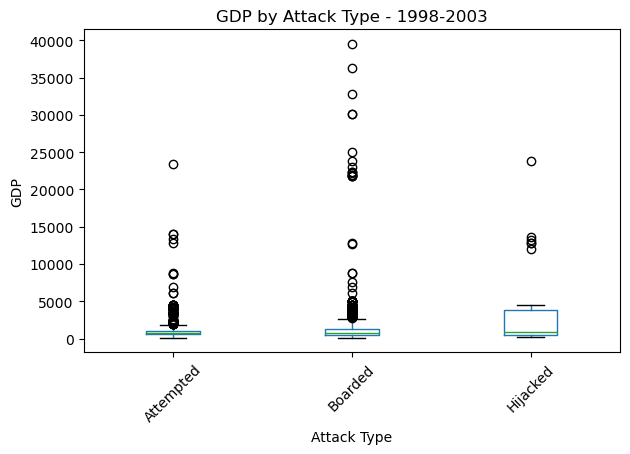

In [13]:
plt.figure(figsize=(10, 6))

merged1.boxplot(
    column='GDP',
    by='attack_type',
    grid=False
)

plt.title('GDP by Attack Type - 1998-2003')
plt.suptitle('')  # removes automatic pandas subtitle
plt.xlabel('Attack Type')
plt.ylabel('GDP')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Check for normal distribution, slice 1

In [14]:
for attack in merged1["attack_type"].unique():
    gdp_group = merged1[merged1["attack_type"] == attack]["GDP"]
    stat, p_value = stats.shapiro(gdp_group)
    
    status = "not normal" if p_value < 0.05 else "normal"
    
    print(f"Attack Type: {attack}")
    print(f"Shapiro-Wilk Statistic: {stat:.4f}")
    print(f"p-value: {p_value:.4e} ({status})\n")

Attack Type: Boarded
Shapiro-Wilk Statistic: 0.3510
p-value: 1.4072e-57 (not normal)

Attack Type: Attempted
Shapiro-Wilk Statistic: 0.5316
p-value: 3.9468e-35 (not normal)

Attack Type: Hijacked
Shapiro-Wilk Statistic: 0.5726
p-value: 1.9366e-15 (not normal)



## Log-transform for normality

In [15]:
#log transformation to GDP
merged1["Log_GDP"] = np.log(merged1["GDP"])

# again shapiro-wilk for normality on log GDP
for attack in merged1["attack_type"].unique():
    log_gdp_group = merged1[merged1["attack_type"] == attack]["Log_GDP"]
    stat, p_value = stats.shapiro(log_gdp_group)

    status = "not normal" if p_value < 0.05 else "normal"

    print(f"Attack Type: {attack}")
    print(f"  Shapiro-Wilk Statistic: {stat:.4f}")
    print(f"  p-value: {p_value:.4e} ({status})\n")

Attack Type: Boarded
  Shapiro-Wilk Statistic: 0.8788
  p-value: 4.2107e-32 (not normal)

Attack Type: Attempted
  Shapiro-Wilk Statistic: 0.9214
  p-value: 5.7647e-16 (not normal)

Attack Type: Hijacked
  Shapiro-Wilk Statistic: 0.9379
  p-value: 1.6819e-04 (not normal)



# Kruskal-Wallis, slice 1

In [24]:
from scipy import stats

# Group GDP values by attack type
groups1 = [group['GDP'].values for _, group in merged1.groupby('attack_type')]

# Kruskal-Wallis test
stat1, p_value1 = stats.kruskal(*groups1)

# Create ranks across ALL GDP observations
merged1['GDP_rank'] = merged1['GDP'].rank(method='average')

# Mean ranks by attack type
mean_ranks = merged1.groupby('attack_type')['GDP_rank'].mean()

#print(mean_ranks.round(2))

summary = merged1.groupby('attack_type')['GDP'].describe()

summary['mean_rank'] = merged1.groupby('attack_type')['GDP_rank'].mean()

print(f'Kruskal-Wallis H-statistic: {stat1:.4f}')
print(f'P-value: {p_value1:.4f}')
print()
print(summary.round(2))

Kruskal-Wallis H-statistic: 7.3220
P-value: 0.0257

              count     mean      std     min     25%     50%      75%  \
attack_type                                                              
Attempted     528.0  1474.15  1985.97  137.17  550.36  780.19  1072.81   
Boarded      1442.0  1580.58  2970.83  102.60  463.95  780.19  1342.49   
Hijacked       98.0  2424.39  3607.44  190.67  464.75  929.78  3808.24   

                  max  mean_rank  
attack_type                       
Attempted    23447.03    1046.18  
Boarded      39496.49    1019.97  
Hijacked     23852.33    1185.39  


# Dunn test, slice 1

In [25]:
import scikit_posthocs as sp

dunn = sp.posthoc_dunn(
    merged1,
    val_col='GDP',
    group_col='attack_type',
    p_adjust='bonferroni'
)
print(dunn.round(4))
print()
print(dunn <0.05)

           Attempted  Boarded  Hijacked
Attempted     1.0000   1.0000    0.1018
Boarded       1.0000   1.0000    0.0238
Hijacked      0.1018   0.0238    1.0000

           Attempted  Boarded  Hijacked
Attempted      False    False     False
Boarded        False    False      True
Hijacked       False     True     False


In [26]:
sig_labels = dunn.copy().astype(str)

for i in range(dunn.shape[0]):
    for j in range(dunn.shape[1]):

        p = dunn.iloc[i, j]

        if p <= 0.001:
            sig_labels.iloc[i, j] = "***"
        elif p <= 0.01:
            sig_labels.iloc[i, j] = "**"
        elif p <= 0.05:
            sig_labels.iloc[i, j] = "*"
        else:
            sig_labels.iloc[i, j] = "ns"

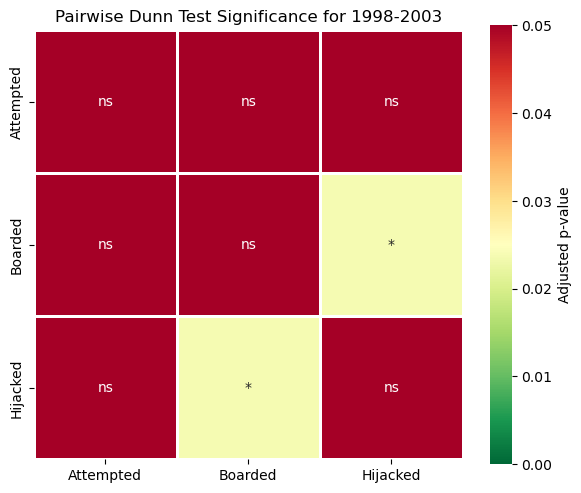

In [27]:
plt.figure(figsize=(6,5))

sns.heatmap(
    dunn,
    annot=sig_labels,
    fmt="",
    cmap="RdYlGn_r",
    vmin=0,
    vmax=0.05,
    linewidths=1,
    square=True,
    cbar_kws={"label": "Adjusted p-value"}
)

plt.title("Pairwise Dunn Test Significance for 1998-2003")
plt.tight_layout()
plt.show()

## (BOX)plotting slice 2

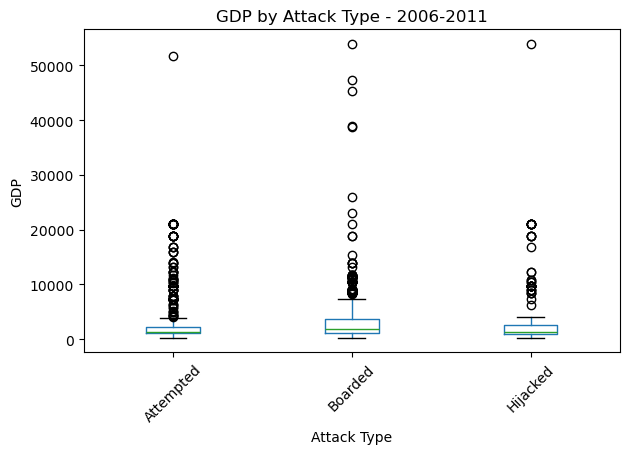

In [28]:
merged2.boxplot(
    column='GDP',
    by='attack_type',
    grid=False
)

plt.title('GDP by Attack Type - 2006-2011')
plt.suptitle('') 
plt.xlabel('Attack Type')
plt.ylabel('GDP')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Check for normal distribution, slice 2

In [29]:
for attack in merged2["attack_type"].unique():
    gdp_group = merged2[merged2["attack_type"] == attack]["GDP"]
    stat, p_value = stats.shapiro(gdp_group)
    
    status = "not normal" if p_value < 0.05 else "normal"
    
    print(f"Attack Type: {attack}")
    print(f"Shapiro-Wilk Statistic: {stat:.4f}")
    print(f"p-value: {p_value:.4e} ({status})\n")

Attack Type: Boarded
Shapiro-Wilk Statistic: 0.5381
p-value: 9.4009e-45 (not normal)

Attack Type: Hijacked
Shapiro-Wilk Statistic: 0.5419
p-value: 5.5482e-22 (not normal)

Attack Type: Attempted
Shapiro-Wilk Statistic: 0.5181
p-value: 5.1193e-39 (not normal)



## Log-transform for normality, slice 2

In [30]:
#log transformation to GDP
merged2["Log_GDP"] = np.log(merged2["GDP"])

# again shapiro-wilk for normality on log GDP
for attack in merged2["attack_type"].unique():
    log_gdp_group = merged2[merged2["attack_type"] == attack]["Log_GDP"]
    stat, p_value = stats.shapiro(log_gdp_group)

    status = "not normal" if p_value < 0.05 else "normal"

    print(f"Attack Type: {attack}")
    print(f"  Shapiro-Wilk Statistic: {stat:.4f}")
    print(f"  p-value: {p_value:.4e} ({status})\n")

Attack Type: Boarded
  Shapiro-Wilk Statistic: 0.9843
  p-value: 9.5905e-09 (not normal)

Attack Type: Hijacked
  Shapiro-Wilk Statistic: 0.8894
  p-value: 1.4312e-10 (not normal)

Attack Type: Attempted
  Shapiro-Wilk Statistic: 0.8609
  p-value: 8.4638e-24 (not normal)



## Kruskal-Wallis, slice 2

In [31]:
merged2 = merged2.copy()
# Group GDP values by attack type
groups2 = [group['GDP'].values for _, group in merged2.groupby('attack_type')]

# Kruskal-Wallis test
stat2, p_value2 = stats.kruskal(*groups2)

print(f'Kruskal-Wallis H-statistic: {stat2:.4f}')
print(f'P-value: {p_value2:.2e}')

merged2['GDP_rank'] = merged2['GDP'].rank(method='average')

# Mean ranks by attack type
mean_ranks2 = merged2.groupby('attack_type')['GDP_rank'].mean()

#print(mean_ranks.round(2))

summary2 = merged2.groupby('attack_type')['GDP'].describe()

summary2['mean_rank'] = merged2.groupby('attack_type')['GDP_rank'].mean()
print(summary2.round(2))


Kruskal-Wallis H-statistic: 50.7504
P-value: 9.54e-12
             count     mean      std    min      25%      50%      75%  \
attack_type                                                              
Attempted    665.0  3218.95  5172.09  219.2  1116.08  1334.78  2242.87   
Boarded      977.0  3216.66  4245.93  235.3  1101.96  1891.34  3643.04   
Hijacked     188.0  3844.54  6482.05  219.2   951.69  1229.25  2520.40   

                  max  mean_rank  
attack_type                       
Attempted    51733.44     826.33  
Boarded      53890.43     997.50  
Hijacked     53890.43     804.80  


## Dunn test, slice 2

In [32]:
dunn2 = sp.posthoc_dunn(
    merged2,
    val_col='GDP',
    group_col='attack_type',
    p_adjust='bonferroni'
)
#print(dunn2.round(4))
print(dunn2.map(lambda x: f'{x:.2e}'))
print()
print(dunn2 <0.05)

          Attempted   Boarded  Hijacked
Attempted  1.00e+00  3.45e-10  1.00e+00
Boarded    3.45e-10  1.00e+00  1.39e-05
Hijacked   1.00e+00  1.39e-05  1.00e+00

           Attempted  Boarded  Hijacked
Attempted      False     True     False
Boarded         True    False      True
Hijacked       False     True     False


In [33]:
sig_labels2 = dunn2.copy().astype(str)

for i in range(dunn2.shape[0]):
    for j in range(dunn2.shape[1]):

        p = dunn2.iloc[i, j]

        if p <= 0.001:
            sig_labels2.iloc[i, j] = "***"
        elif p <= 0.01:
            sig_labels2.iloc[i, j] = "**"
        elif p <= 0.05:
            sig_labels2.iloc[i, j] = "*"
        else:
            sig_labels2.iloc[i, j] = "ns"

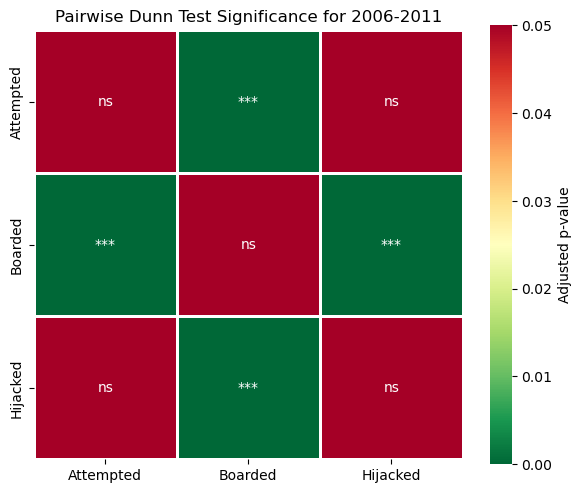

In [34]:
plt.figure(figsize=(6,5))

sns.heatmap(
    dunn2,
    annot=sig_labels2,
    fmt="",
    cmap="RdYlGn_r",
    vmin=0,
    vmax=0.05,
    linewidths=1,
    square=True,
    cbar_kws={"label": "Adjusted p-value"}
)

plt.title("Pairwise Dunn Test Significance for 2006-2011")
plt.tight_layout()
plt.show()